# Fed Rate-Change Event Study: Market-Wide Reaction & AAPL Abnormal Return

**A note on scope**: events here are the 31 dates where the Fed Funds Target
Rate actually *changed* (derived from `DFEDTARU.diff()`), not every FOMC
meeting. FOMC meetings that left rates unchanged ("held") are not included —
so this is precisely a study of **market reaction to Fed rate changes**,
a narrower and more precisely-defined scope than "reaction to FOMC meetings"
in general.

**Research questions**
1. **(Part A)** Does the U.S. equity market (SPY) exhibit abnormal
   return/volatility around Fed rate-change dates?
2. **(Part B)** If so, does AAPL react *differently* from what its market
   beta alone would predict (i.e., does it show a genuine abnormal return),
   using a Market-Model event study?

**Data**
- SPY & AAPL daily prices, 2013-01 to 2026-08 (Yahoo Finance via `yfinance`)
- Fed Funds Target Rate (Upper Limit), daily, 2008-2026 (FRED series `DFEDTARU`)
- 31 rate-change dates (20 hikes, 11 cuts) derived directly from `DFEDTARU`
  via `.diff()` — no manually-compiled meeting calendar needed, and every
  date is independently verifiable against the source series.

**Method**
- **Part A**: event-study design (Fama, Fisher, Jensen & Roll, 1969).
  For each event, aggregate its own [-1,0,+1] window into a single per-event
  average, then test the 31 event-level averages against the normal-day
  baseline. Statistical unit = **event** (n=31), not daily observation
  (n=93) — the 3 days within one event window are not independent of each
  other, so pooling them as if they were would understate the true standard
  error. (An exploratory daily-pooled version is also shown for comparison.)
- **Part B**: Market-Model event study (MacKinlay, 1997). For each event,
  estimate AAPL's alpha/beta against SPY on a prior estimation window
  ([-141,-21] trading days, ending 21 days before the event to avoid
  leakage), then compute Abnormal Return = actual − (alpha + beta × market
  return) inside the event window, summed into a Cumulative Abnormal Return
  (CAR) per event. Robustness: since CAR residuals fail normality (Jarque-Bera)
  and show heteroskedasticity (ARCH-LM), results are cross-checked with a
  non-parametric Wilcoxon signed-rank test and a bootstrap confidence
  interval, alongside the parametric t-test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_arch

%matplotlib inline

## 0. Load raw data (shared by Part A and Part B)

In [2]:
# --- SPY (market benchmark) ---
spy = pd.read_csv("spy_2013_2026.csv", skiprows=[1, 2]).rename(columns={"Price": "Date"})
spy["Date"] = pd.to_datetime(spy["Date"])
spy = spy.sort_values("Date").reset_index(drop=True)
spy["mkt_ret"] = spy["Close"].pct_change()

# --- AAPL ---
aapl = pd.read_csv("aapl_2013_2026.csv", skiprows=[1, 2]).rename(columns={"Price": "Date"})
aapl["Date"] = pd.to_datetime(aapl["Date"])
aapl = aapl.sort_values("Date").reset_index(drop=True)
aapl["aapl_ret"] = aapl["Close"].pct_change()

# --- Fed Funds Target Rate (Upper Limit) -> rate-change event dates ---
fed = pd.read_csv("DFEDTARU.csv", parse_dates=["observation_date"]).sort_values("observation_date").reset_index(drop=True)
fed["change"] = fed["DFEDTARU"].diff()
fed["direction"] = np.sign(fed["change"])  # +1 = hike, -1 = cut

sample_start, sample_end = spy["Date"].min(), spy["Date"].max()
rate_events = fed.loc[(fed["change"] != 0) &
                       (fed["observation_date"] >= sample_start) &
                       (fed["observation_date"] <= sample_end),
                       ["observation_date", "direction"]].reset_index(drop=True)

rate_changes = rate_events["observation_date"].tolist()
hike_dates = rate_events.loc[rate_events["direction"] == 1, "observation_date"].tolist()
cut_dates = rate_events.loc[rate_events["direction"] == -1, "observation_date"].tolist()

print(f"SPY: {len(spy)} trading days ({sample_start.date()} to {sample_end.date()})")
print(f"AAPL: {len(aapl)} trading days")
print(f"Rate-change events: {len(rate_changes)} total "
      f"({len(hike_dates)} hikes, {len(cut_dates)} cuts)")

SPY: 3431 trading days (2013-01-02 to 2026-08-24)
AAPL: 3431 trading days
Rate-change events: 31 total (20 hikes, 11 cuts)


In [3]:
trading_dates = spy["Date"].tolist()

def nearest_trading_day(target_date, dates):
    """Snap an event date to the nearest actual trading day
    (handles weekends/holidays)."""
    diffs = [abs((d - target_date).days) for d in dates]
    return dates[int(np.argmin(diffs))]

## Part A — Does the market react around FOMC rate-change dates?

Test asset: **SPY** (the market itself — no benchmark needed). Event window:
[-1, 0, +1] trading days around each of the 31 rate-change dates.

In [4]:
spy["ret"] = spy["mkt_ret"]
spy["abs_ret"] = spy["ret"].abs()
spy = spy.dropna(subset=["ret"]).reset_index(drop=True)
trading_dates = spy["Date"].tolist()  # refresh after dropna

WINDOW = 1
event_indices = set()
for d in rate_changes:
    anchor = nearest_trading_day(d, trading_dates)
    idx = trading_dates.index(anchor)
    for offset in range(-WINDOW, WINDOW + 1):
        i = idx + offset
        if 0 <= i < len(trading_dates):
            event_indices.add(i)

spy["is_event"] = spy.index.isin(event_indices)
print(f"Event-window days: {spy['is_event'].sum()} / {len(spy)}")

Event-window days: 93 / 3430


In [5]:
event_ret = spy.loc[spy["is_event"], "ret"]
normal_ret = spy.loc[~spy["is_event"], "ret"]
event_abs = spy.loc[spy["is_event"], "abs_ret"]
normal_abs = spy.loc[~spy["is_event"], "abs_ret"]

# Exploratory version: pool all 93 event-window days as if independent.
# (Kept for comparison, but see the event-level test below — 3 days from
# the same event are correlated, so this likely understates the true SE.)
t1, p1 = stats.ttest_ind(event_ret, normal_ret, equal_var=False)
t2, p2 = stats.ttest_ind(event_abs, normal_abs, equal_var=False)

print("[Daily-pooled, exploratory — statistical unit = day, n=93]")
print("H1 - Return: event={:.5f}, normal={:.5f}, t={:.3f}, p={:.4f}".format(
    event_ret.mean(), normal_ret.mean(), t1, p1))
print("H2 - |Return| (proxy for volatility): event={:.5f}, normal={:.5f}, t={:.3f}, p={:.4f}".format(
    event_abs.mean(), normal_abs.mean(), t2, p2))

[Daily-pooled, exploratory — statistical unit = day, n=93]
H1 - Return: event=-0.00117, normal=0.00066, t=-0.844, p=0.4011
H2 - |Return| (proxy for volatility): event=0.01279, normal=0.00682, t=3.501, p=0.0007


**Event-level test** (statistical unit = event, n=31): for each event,
average its own [-1,0,+1] window into a single number, then test those 31
event-level averages against the normal-day baseline. This avoids treating
3 correlated days as 3 independent observations.

In [6]:
event_level_rows = []
for d in rate_changes:
    anchor = nearest_trading_day(d, trading_dates)
    idx = trading_dates.index(anchor)
    window_rows = spy.iloc[max(0, idx - WINDOW): idx + WINDOW + 1]
    event_level_rows.append({
        "event_date": d,
        "avg_ret": window_rows["ret"].mean(),
        "avg_abs_ret": window_rows["abs_ret"].mean(),
    })
event_level_df = pd.DataFrame(event_level_rows)

# One-sample t-test: does the event-level average differ from the normal-day mean?
t1e, p1e = stats.ttest_1samp(event_level_df["avg_ret"], normal_ret.mean())
t2e, p2e = stats.ttest_1samp(event_level_df["avg_abs_ret"], normal_abs.mean())

print("[Event-level — statistical unit = event, n=31]")
print("H1 - Return: event-level mean={:.5f}, normal baseline={:.5f}, t={:.3f}, p={:.4f}".format(
    event_level_df["avg_ret"].mean(), normal_ret.mean(), t1e, p1e))
print("H2 - |Return| (proxy for volatility): event-level mean={:.5f}, normal baseline={:.5f}, t={:.3f}, p={:.4f}".format(
    event_level_df["avg_abs_ret"].mean(), normal_abs.mean(), t2e, p2e))
print(f"\n-> H2 is {'SIGNIFICANT' if p2e < 0.05 else 'not significant'} at the 5% level "
      f"under the more conservative event-level test.")

# Use the event-level p-value going forward — it's the more defensible one.
p2 = p2e

[Event-level — statistical unit = event, n=31]
H1 - Return: event-level mean=-0.00117, normal baseline=0.00066, t=-1.268, p=0.2147
H2 - |Return| (proxy for volatility): event-level mean=0.01279, normal baseline=0.00682, t=2.221, p=0.0341

-> H2 is SIGNIFICANT at the 5% level under the more conservative event-level test.


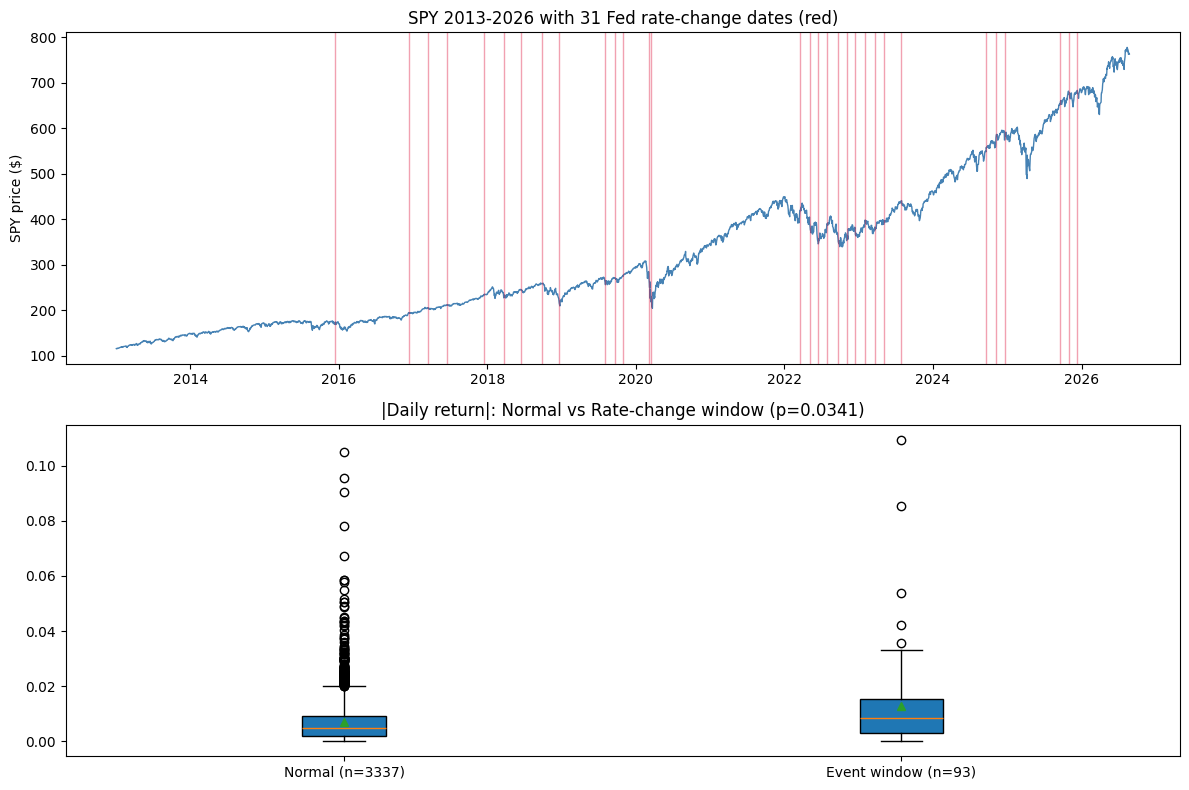

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(spy["Date"], spy["Close"], color="steelblue", lw=1)
for d in rate_changes:
    axes[0].axvline(nearest_trading_day(d, trading_dates), color="crimson", alpha=0.4, lw=1)
axes[0].set_title(f"SPY 2013-2026 with {len(rate_changes)} Fed rate-change dates (red)")
axes[0].set_ylabel("SPY price ($)")

axes[1].boxplot([normal_abs.values, event_abs.values],
                 tick_labels=[f"Normal (n={len(normal_abs)})", f"Event window (n={len(event_abs)})"],
                 patch_artist=True, showmeans=True)
axes[1].set_title(f"|Daily return|: Normal vs Rate-change window (p={p2:.4f})")

plt.tight_layout()
plt.savefig("part_a_market_reaction.png", dpi=150)
plt.show()

## Part B — Does AAPL react *differently* from the market? (Market-Model event study)

Part A showed the market as a whole reacts. This asks a sharper question:
after accounting for AAPL's normal co-movement with the market (its beta),
is there anything *left over* — an abnormal return specific to AAPL?

For each event: estimate alpha/beta on a clean prior window (no overlap with
any event window), then compute Abnormal Return = actual − expected in the
[-1,0,+1] window, summed into a CAR per event.

In [8]:
df = pd.merge(aapl[["Date", "aapl_ret"]], spy[["Date", "mkt_ret"]], on="Date").dropna().reset_index(drop=True)
event_trading_dates = df["Date"].tolist()

print(f"{len(df)} trading days with both AAPL and SPY returns "
      f"({df['Date'].min().date()} to {df['Date'].max().date()})")

3430 trading days with both AAPL and SPY returns (2013-01-03 to 2026-08-24)


In [9]:
def estimate_event(event_date, est_len=120, gap=21, window=1):
    """
    Estimate AAPL's market-model (alpha, beta) on a [-141,-21] trading-day
    window before the event (21-day gap avoids any leakage from the event
    itself), then compute the Cumulative Abnormal Return over [-1,0,+1].
    Returns None if there isn't enough prior history (only affects events
    very early in the sample).
    """
    anchor = nearest_trading_day(event_date, event_trading_dates)
    idx = event_trading_dates.index(anchor)

    est_start, est_end = idx - gap - est_len, idx - gap
    if est_start < 0:
        return None

    est_data = df.iloc[est_start:est_end]
    X = sm.add_constant(est_data["mkt_ret"])
    model = sm.OLS(est_data["aapl_ret"], X).fit()
    alpha, beta = model.params["const"], model.params["mkt_ret"]

    event_rows = df.iloc[max(0, idx - window): idx + window + 1]
    expected = alpha + beta * event_rows["mkt_ret"]
    ar = event_rows["aapl_ret"] - expected

    return {"event_date": event_date, "alpha": alpha, "beta": beta,
            "car": ar.sum(), "residuals": model.resid}

In [10]:
# Compute once per event, reuse the result (avoids re-running OLS twice per event)
event_results = {d: estimate_event(d) for d in rate_changes}
event_results = {d: r for d, r in event_results.items() if r is not None}

car_df = pd.DataFrame([
    {"event_date": d, "direction": "hike" if fed_dir == 1 else "cut",
     "alpha": r["alpha"], "beta": r["beta"], "car": r["car"]}
    for d, r in event_results.items()
    for fed_dir in [rate_events.loc[rate_events["observation_date"] == d, "direction"].iloc[0]]
]).sort_values("event_date").reset_index(drop=True)

print(f"CAR computed for {len(car_df)} / {len(rate_changes)} events")
car_df

CAR computed for 31 / 31 events


,event_date,direction,alpha,beta,car
0,2015-12-16,hike,-0.000810,1.139603,-0.040037
1,2016-12-14,hike,0.000665,0.785075,0.018163
2,2017-03-16,hike,0.001397,0.731801,-0.000563
3,2017-06-15,hike,0.002213,0.891470,-0.033737
4,2017-12-14,hike,0.000071,1.637087,0.006220
5,2018-03-22,hike,-0.000466,1.160075,-0.002591
6,2018-06-14,hike,0.000377,1.078071,-0.016994
7,2018-09-27,hike,0.001348,1.053716,0.012153
8,2018-12-20,hike,0.000267,1.377352,-0.024856
9,2019-08-01,cut,0.000653,1.534930,0.017363


### B1. Does AAPL show an abnormal return, pooling all 31 events?

H0: mean CAR = 0 (no abnormal return, on average, across all rate-change events).

In [11]:
t_car, p_car = stats.ttest_1samp(car_df["car"], 0)
print(f"CAR mean (all events): {car_df['car'].mean():.5f}")
print(f"t-stat: {t_car:.3f}, p-value: {p_car:.4f}")
print(f"-> {'SIGNIFICANT' if p_car < 0.05 else 'NOT significant'} at the 5% level")

CAR mean (all events): 0.00223
t-stat: 0.532, p-value: 0.5988
-> NOT significant at the 5% level


**Robustness check**: the Market-Model residuals failed the Jarque-Bera
normality test and the ARCH-LM heteroskedasticity test (see B3 below) —
both assumptions the one-sample t-test above leans on. Two distribution-free
cross-checks: a **Wilcoxon signed-rank test** (tests whether the median CAR
differs from 0, no normality assumption) and a **bootstrap 95% confidence
interval** for the mean CAR (resampling the 31 events with replacement,
10,000 times).

In [12]:
from scipy.stats import wilcoxon

w_stat, w_p = wilcoxon(car_df["car"])
print(f"Wilcoxon signed-rank test: stat={w_stat:.1f}, p={w_p:.4f} "
      f"-> {'SIGNIFICANT' if w_p < 0.05 else 'NOT significant'}")

rng = np.random.default_rng(42)
boot_means = np.array([
    rng.choice(car_df["car"], size=len(car_df), replace=True).mean()
    for _ in range(10_000)
])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"\nBootstrap 95% CI for mean CAR: [{ci_low:.5f}, {ci_high:.5f}] "
      f"-> {'excludes 0 (significant)' if ci_low > 0 or ci_high < 0 else 'includes 0 (not significant)'}")

Wilcoxon signed-rank test: stat=207.0, p=0.4327 -> NOT significant



Bootstrap 95% CI for mean CAR: [-0.00608, 0.01009] -> includes 0 (not significant)


### B2. Does the sign of the rate decision matter? (hikes vs. cuts)

Pooling hikes and cuts together risks masking a real effect if they push AAPL
in opposite directions — an economically plausible hypothesis (rate cuts
lower the discount rate applied to AAPL's future cash flows; hikes raise it).
Splitting the sample checks this directly.

**Caveat**: this is a post-hoc split done *because* the pooled test came back
null — a legitimate hypothesis given the economics, but also exactly the kind
of multiple-comparison fishing that can manufacture a "finding" by chance.
The cut-only result below should be read as suggestive, not confirmatory,
especially at n=11.

In [13]:
car_hikes = car_df.loc[car_df["direction"] == "hike", "car"]
car_cuts = car_df.loc[car_df["direction"] == "cut", "car"]

t_h, p_h = stats.ttest_1samp(car_hikes, 0)
t_c, p_c = stats.ttest_1samp(car_cuts, 0)
w_h, wp_h = wilcoxon(car_hikes)
w_c, wp_c = wilcoxon(car_cuts)

print(f"Hikes only (n={len(car_hikes)}): mean CAR={car_hikes.mean():.5f}")
print(f"  t-test:   t={t_h:.3f}, p={p_h:.4f}")
print(f"  Wilcoxon: p={wp_h:.4f}")
print(f"\nCuts only  (n={len(car_cuts)}): mean CAR={car_cuts.mean():.5f}")
print(f"  t-test:   t={t_c:.3f}, p={p_c:.4f}")
print(f"  Wilcoxon: p={wp_c:.4f}")
print(f"\n-> With n=11, the cut-only result should be read as suggestive at best "
      f"regardless of which test is used — both are well short of the 5% "
      f"threshold needed for confirmatory evidence.")

Hikes only (n=20): mean CAR=-0.00232
  t-test:   t=-0.415, p=0.6829
  Wilcoxon: p=0.8983

Cuts only  (n=11): mean CAR=0.01050
  t-test:   t=1.902, p=0.0864
  Wilcoxon: p=0.1016

-> With n=11, the cut-only result should be read as suggestive at best regardless of which test is used — both are well short of the 5% threshold needed for confirmatory evidence.


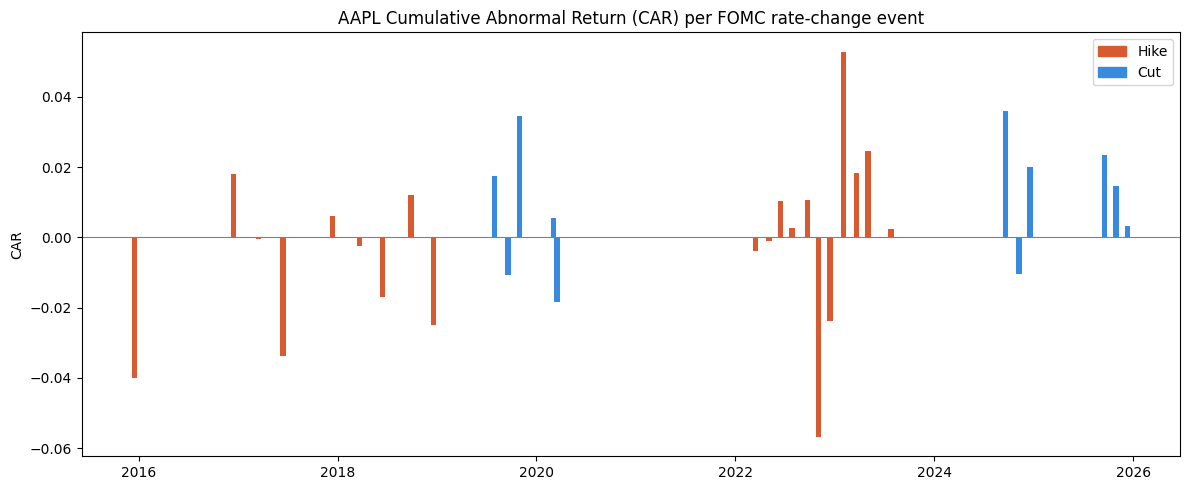

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = car_df["direction"].map({"hike": "#D85A30", "cut": "#378ADD"})
ax.bar(car_df["event_date"], car_df["car"], color=colors, width=20)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("AAPL Cumulative Abnormal Return (CAR) per FOMC rate-change event")
ax.set_ylabel("CAR")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#D85A30", label="Hike"), Patch(color="#378ADD", label="Cut")])
plt.tight_layout()
plt.savefig("part_b_car_by_event.png", dpi=150)
plt.show()

### B3. Diagnostics on the Market-Model residuals

Pooled across all 31 estimation windows. Note these windows span very
different volatility regimes (2016 vs. 2022, for example), so some
heteroskedasticity here is expected simply from pooling regimes together —
not necessarily a defect in any single event's regression.

In [15]:
all_residuals = np.concatenate([r["residuals"].values for r in event_results.values()])

jb_stat, jb_pvalue, skew, kurt = jarque_bera(all_residuals)
print(f"Jarque-Bera (normality):     stat={jb_stat:.2f}, p={jb_pvalue:.4f} "
      f"-> {'residuals NOT normal' if jb_pvalue < 0.05 else 'normality not rejected'}")
print(f"  Skewness={skew:.3f}, Kurtosis={kurt:.3f} (Normal: 0, 3)")

arch_stat, arch_pvalue, _, _ = het_arch(all_residuals)
print(f"\nARCH-LM (heteroskedasticity): stat={arch_stat:.2f}, p={arch_pvalue:.4f} "
      f"-> {'heteroskedasticity present' if arch_pvalue < 0.05 else 'not detected'}")

dw_stat = durbin_watson(all_residuals)
print(f"\nDurbin-Watson (autocorrelation): {dw_stat:.3f} (2.0 = ideal, <1.5 or >2.5 = concerning)")

Jarque-Bera (normality):     stat=4117.90, p=0.0000 -> residuals NOT normal
  Skewness=0.696, Kurtosis=7.963 (Normal: 0, 3)

ARCH-LM (heteroskedasticity): stat=52.05, p=0.0000 -> heteroskedasticity present

Durbin-Watson (autocorrelation): 1.842 (2.0 = ideal, <1.5 or >2.5 = concerning)


## Summary

In [16]:
print("=" * 66)
print("PART A — Market-wide reaction (SPY), event-level test (n=31)")
print("=" * 66)
print(f"  Volatility (|return| proxy) around Fed rate changes vs normal days:")
print(f"    p = {p2e:.4f} ({'significant' if p2e < 0.05 else 'not significant'})")

print("\n" + "=" * 66)
print("PART B — AAPL-specific abnormal return (Market Model)")
print("=" * 66)
print(f"  All 31 events pooled:  t-test p = {p_car:.4f}, Wilcoxon p = {w_p:.4f}, "
      f"bootstrap 95% CI = [{ci_low:.5f}, {ci_high:.5f}]")
print(f"  Hikes only (n={len(car_hikes)}):     t-test p = {p_h:.4f}, Wilcoxon p = {wp_h:.4f}")
print(f"  Cuts only  (n={len(car_cuts)}):     t-test p = {p_c:.4f}, Wilcoxon p = {wp_c:.4f}")

print("\nInterpretation: the market as a whole reacts significantly to Fed rate")
print("changes, and this holds under the more conservative event-level test.")
print("AAPL's reaction is fully explained by its market beta -- no significant")
print("AAPL-specific abnormal return under either the parametric or non-parametric")
print("test. The cut-only split hints at an asymmetric (cuts > hikes) effect, but")
print("at n=11 this is suggestive at best and should not be treated as confirmed.")

PART A — Market-wide reaction (SPY), event-level test (n=31)
  Volatility (|return| proxy) around Fed rate changes vs normal days:
    p = 0.0341 (significant)

PART B — AAPL-specific abnormal return (Market Model)
  All 31 events pooled:  t-test p = 0.5988, Wilcoxon p = 0.4327, bootstrap 95% CI = [-0.00608, 0.01009]
  Hikes only (n=20):     t-test p = 0.6829, Wilcoxon p = 0.8983
  Cuts only  (n=11):     t-test p = 0.0864, Wilcoxon p = 0.1016

Interpretation: the market as a whole reacts significantly to Fed rate
changes, and this holds under the more conservative event-level test.
AAPL's reaction is fully explained by its market beta -- no significant
AAPL-specific abnormal return under either the parametric or non-parametric
test. The cut-only split hints at an asymmetric (cuts > hikes) effect, but
at n=11 this is suggestive at best and should not be treated as confirmed.
